In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Read data/csv

In [29]:
df = pd.read_csv('Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [30]:
df.shape

(7043, 21)

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [32]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [33]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [34]:
df.duplicated().sum()

np.int64(0)

# EDA + Data Cleaning

In [35]:
# 1. See the exact number of customers in each group
print("Exact Counts:")
print(df['Churn'].value_counts())

# 2. See the percentage breakdown (normalize=True gives us the fractions)
print("\nPercentage Breakdown:")
print(df['Churn'].value_counts(normalize=True) * 100)

Exact Counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Percentage Breakdown:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [36]:
# dropping the ID column
df.drop('customerID', axis=1, inplace=True)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [37]:
# filter the dataset to only show customers who have been here for 0 months
df[df['tenure'] == 0]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [38]:
# Force 'TotalCharges' to become numeric.
# errors='coerce' tells Pandas: "If you find text like a blank space, turn it into NaN"
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [39]:
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


/tmp/ipykernel_1341/3508692731.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='Set2')


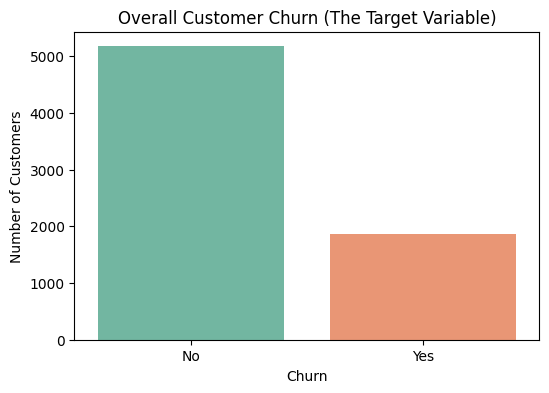

In [40]:
# Checking Imbalance
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn', palette='Set2')
plt.title('Overall Customer Churn (The Target Variable)')
plt.ylabel('Number of Customers')
plt.show()

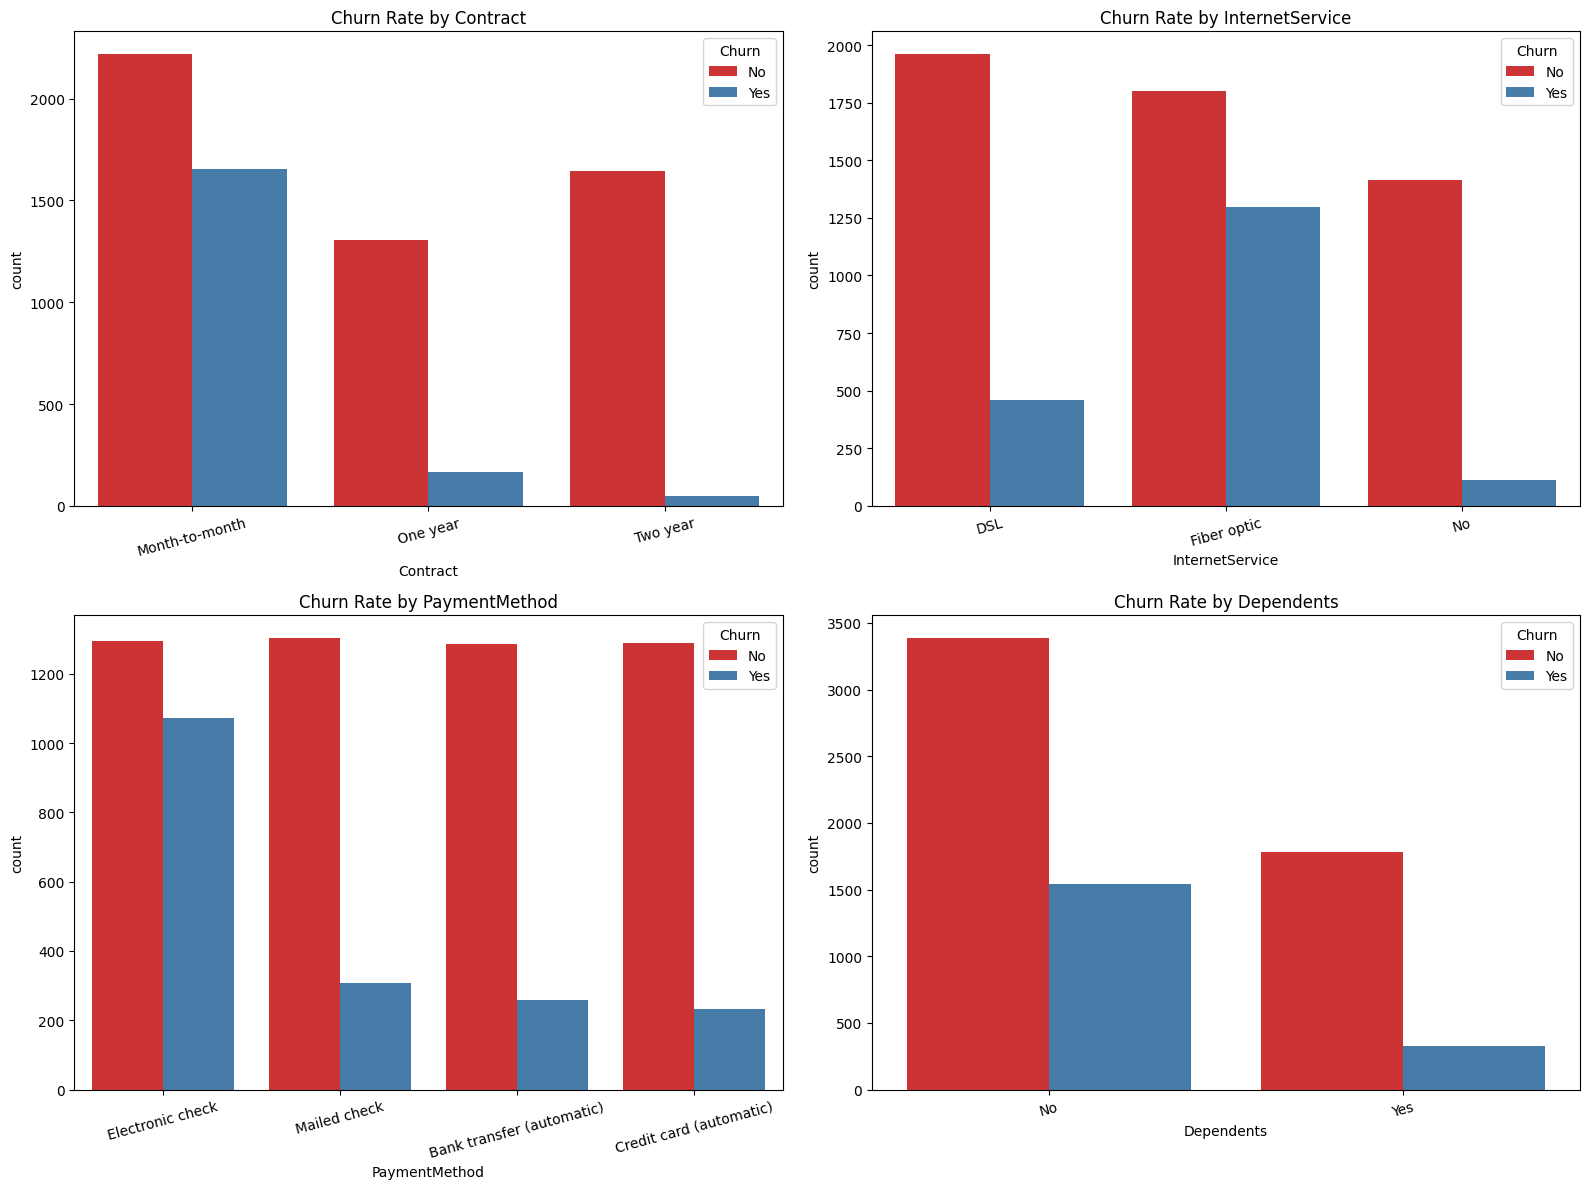

In [41]:
# Categorical Features vs Churn

categorical_cols = ['Contract', 'InternetService', 'PaymentMethod', 'Dependents']
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(data=df, x=col, hue='Churn', ax=axes[i], palette='Set1')
    axes[i].set_title(f'Churn Rate by {col}')
    axes[i].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1341/2673871512.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y=col, ax=axes[i], palette='Pastel1')
/tmp/ipykernel_1341/2673871512.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y=col, ax=axes[i], palette='Pastel1')
/tmp/ipykernel_1341/2673871512.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y=col, ax=axes[i], palette='Pastel1')


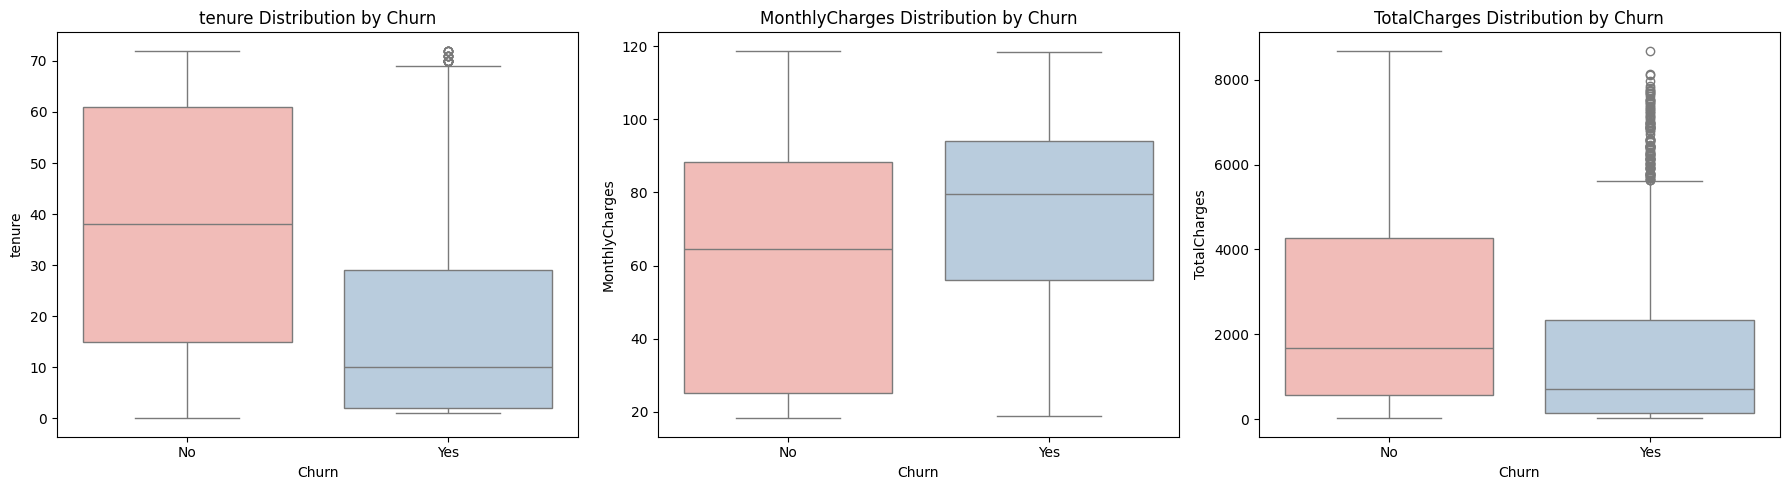

In [42]:
# Numerical Features vs Churn

numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(numerical_cols):
    sns.boxplot(data=df, x='Churn', y=col, ax=axes[i], palette='Pastel1')
    axes[i].set_title(f'{col} Distribution by Churn')

plt.tight_layout()
plt.show()

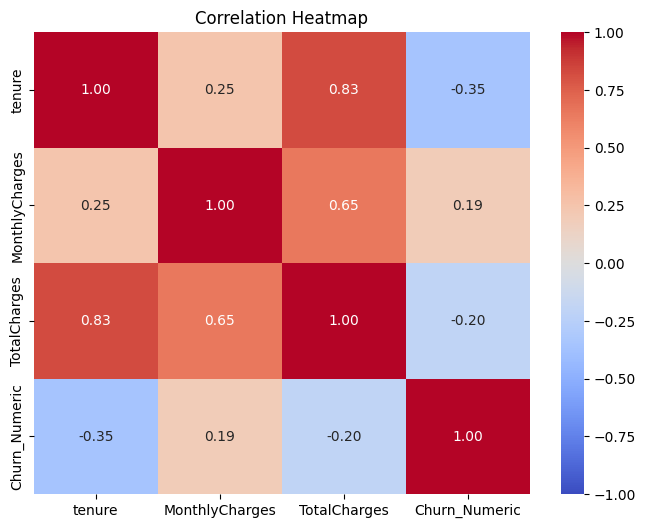

In [43]:
# Correlation Heatmap

df_temp = df[numerical_cols].copy()
df_temp['Churn_Numeric'] = df['Churn'].map({'Yes': 1, 'No': 0})

plt.figure(figsize=(8, 6))
sns.heatmap(df_temp.corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()

In [44]:
# dropping the 11 rows with NaN values in TotalCharges
df.dropna( inplace=True)

# verify shape to see rows -11
df.shape

(7032, 20)

In [45]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [46]:
# grouping the internet-related columns together
internet_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in internet_cols:
  df[col] = df[col].replace({'No internet service': 'No'})

df['MultipleLines'] = df['MultipleLines'].replace({'No internet service': 'No'})

# checking if it worked
print("TechSupport unique values:", df['TechSupport'].unique())
print("MultipleLines unique values:", df['MultipleLines'].unique())

TechSupport unique values: ['No' 'Yes']
MultipleLines unique values: ['No phone service' 'No' 'Yes']


In [47]:
df['MultipleLines'] = df['MultipleLines'].replace({'No phone service': 'No'})

print("MultipleLines unique values:", df['MultipleLines'].unique())

MultipleLines unique values: ['No' 'Yes']


In [48]:
# Feature Engineering: binning

# 1. Define the edges of the bins (in months)
bins = [0, 12, 24, 48, 60, 72]

# 2. Give each bin a readable label
labels = ['0-1 yr', '1-2 yrs', '2-4 yrs', '4-5 yrs', '5-6 yrs']

# 3. Use pd.cut() to sort the tenure numbers into the new bins
df['Tenure_Group'] = pd.cut(df['tenure'], bins=bins, labels=labels)

# 4. Drop the old 'tenure' column because it's now redundant
df.drop('tenure', axis=1, inplace=True)

# 5. Let's see how many customers fall into each group!
print(df['Tenure_Group'].value_counts())

Tenure_Group
0-1 yr     2175
2-4 yrs    1594
5-6 yrs    1407
1-2 yrs    1024
4-5 yrs     832
Name: count, dtype: int64


In [49]:
# encoding

# 1. Manually encode the Target Variable
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df.head()

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Tenure_Group
0,Female,0,Yes,No,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0-1 yr
1,Male,0,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0,2-4 yrs
2,Male,0,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,0-1 yr
3,Male,0,No,No,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,2-4 yrs
4,Female,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,0-1 yr


In [50]:
# 2. Automatically One-Hot Encode all other text columns
# drop_first=True prevents redundant columns, dtype=int makes them 1s and 0s
df = pd.get_dummies(df, drop_first=True, dtype=int)


print("New Dataset Shape:", df.shape)
df.head()

New Dataset Shape: (7032, 27)


,SeniorCitizen,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_Yes,InternetService_Fiber optic,...,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Tenure_Group_1-2 yrs,Tenure_Group_2-4 yrs,Tenure_Group_4-5 yrs,Tenure_Group_5-6 yrs
0,0,29.85,29.85,0,0,1,0,0,0,0,...,0,0,1,0,1,0,0,0,0,0
1,0,56.95,1889.50,0,1,0,0,1,0,0,...,1,0,0,0,0,1,0,1,0,0
2,0,53.85,108.15,1,1,0,0,1,0,0,...,0,0,1,0,0,1,0,0,0,0
3,0,42.30,1840.75,0,1,0,0,0,0,0,...,1,0,0,0,0,0,0,1,0,0
4,0,70.70,151.65,1,0,0,0,1,0,1,...,0,0,1,0,1,0,0,0,0,0


# ML phase: data split, handle data imbalance, model training, testing n eval

In [51]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (5625, 26)
Testing data shape: (1407, 26)


In [52]:
from xgboost import XGBClassifier

# Calculate the Imbalance Ratio

majority_class = y_train.value_counts()[0]
minority_class = y_train.value_counts()[1]
imbalance_ratio = majority_class / minority_class

print(f"Imbalance Ratio: {imbalance_ratio:.2f}")

Imbalance Ratio: 2.76


In [53]:
# Initializing the Model
# passing the imbalance_ratio to scale_pos_weight so it knows to pay extra attention to churners
model = XGBClassifier(scale_pos_weight=imbalance_ratio, random_state=42)

# Train the XGBoost Model
model.fit(X_train, y_train)
print("Model Training Complete!")

Model Training Complete!


--- Classification Report ---
              precision    recall  f1-score   support

           0       0.87      0.77      0.82      1033
           1       0.52      0.69      0.59       374

    accuracy                           0.75      1407
   macro avg       0.70      0.73      0.70      1407
weighted avg       0.78      0.75      0.76      1407


--- Confusion Matrix ---


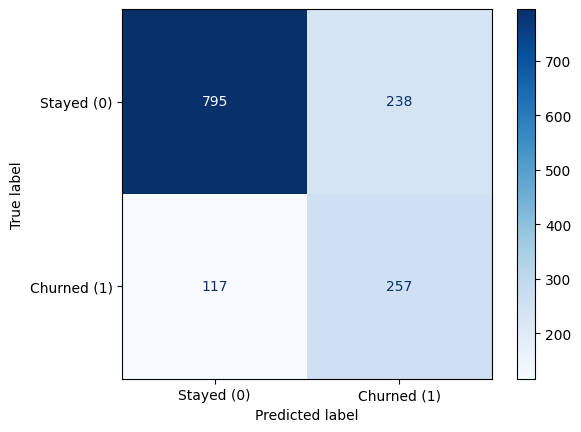

In [54]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# predict for test data
y_pred = model.predict(X_test)

# Print results
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

# Draw a visual Confusion Matrix
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed (0)', 'Churned (1)'])
disp.plot(cmap='Blues')
plt.show()

In [55]:
# using other models to compare performance
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, precision_score, f1_score

# Initializing the Models
# ALL of them handle class imbalance
models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(class_weight='balanced', random_state=42)
}

results = []

for name, model in models.items():
  print(f"Training {name}...")

  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)

  # Calculate metrics
  recall = recall_score(y_test, y_pred)
  precision = precision_score(y_test, y_pred)
  f1 = f1_score(y_test, y_pred)

  # Store results
  results.append({
        "Model": name,
        "Recall": round(recall, 3),
        "Precision": round(precision, 3),
        "F1-Score": round(f1, 3)
  })

# Display the results nicely using a Pandas DataFrame
print("\n--- Results of all Models ---")
results_df = pd.DataFrame(results)
print(results_df)

Training Logistic Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training Random Forest...

--- Results of all Models ---
                 Model  Recall  Precision  F1-Score
0  Logistic Regression   0.781      0.490     0.602
1        Random Forest   0.481      0.619     0.541


In [56]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

# Define the parameter grid to search
# parameters to control the complexity of the trees
param_grid = {
    'max_depth': [3, 4, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200]
}

# setup Grid Search
# We use 'recall' as our scoring metric to focus on catching churners
grid_search = GridSearchCV(
    estimator=XGBClassifier(scale_pos_weight=imbalance_ratio, random_state=42),
    param_grid=param_grid,
    scoring='recall',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# select the best version
best_model = grid_search.best_estimator_
tuned_y_pred = best_model.predict(X_test)

# Print the best parameters and the corresponding score
print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)
print(classification_report(y_test, tuned_y_pred))

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best Parameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}
Best Score: 0.8474916387959865
              precision    recall  f1-score   support

           0       0.91      0.64      0.75      1033
           1       0.45      0.83      0.59       374

    accuracy                           0.69      1407
   macro avg       0.68      0.73      0.67      1407
weighted avg       0.79      0.69      0.71      1407

